In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [2]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                 # max_files =100
                                  max_files =1
                                )

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    'justCC',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]


Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Applying ljs |eta| < 2.4

Applying ljs pT > 30 GeV

Applying cut: PV filter

Applying cut: pass triggers

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


In [6]:
out[samples[0]]["cutflow"][channels[0]].print_table()
print()
#this is only the event cuts

cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection           28221812.0   28221812.0
PV filter              28221812.0   28221812.0
pass triggers            503841.0     503841.0



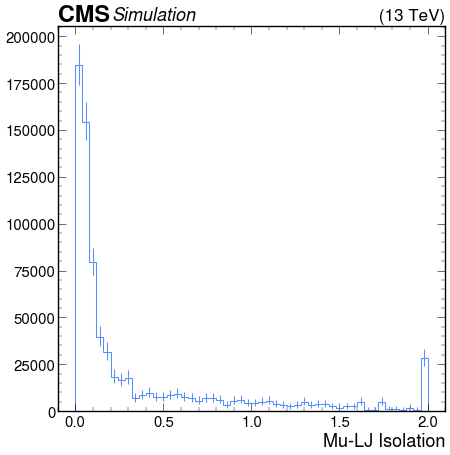

Hist(
  StrCategory(['justCC'], name='channel'),
  Regular(50, 0, 2, name='mu_lj_isolation', label='Mu-LJ Isolation'),
  storage=Weight()) # Sum: WeightedSum(value=723088, variance=4.41602e+08) (WeightedSum(value=753624, variance=4.6025e+08) with flow)


In [21]:
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation_NaN"][channels[0], ::])
plt.show()
print(out[samples[0]]["hists"]["mu_lj_isolation_NaN"])

In [2]:
obj_labels = {
    "electrons": "Electron",
    "photons": "Photon",
    "muons": "PF Muon",
    "dsaMuons": "DSA Muon",
    "ljs": "Lepton Jet",
    "mu_ljs": r"$\mu$-type Lepton Jet",
    "egm_ljs": r"$e\gamma$-type Lepton Jet",
    "genAs": r"$Z_d$",
    "genAs_toMu": r"$Z_d\rightarrow \mu\mu$",
    "genAs_toE": r"$Z_d\rightarrow ee$",
    "pvs": "PV",
    "genMus_fromA": r"Gen $\mu$ (from $Z_d$)",
    "genEs_fromA":  r"Gen $e$ (from $Z_d$)",
    "genBSs_toA":  r"Gen BS (to $Z_d$)",
    "genBS_from_genAs": r"BS (reco from Gen $Z_d$)"
}

attr_labels = {
    "pt": r"$p_T$ (GeV)",
    "eta": r"$\eta$",
    "phi": r"$\phi$",
    "lxy": r"$L_{{xy}}$ (cm) ",
    "dxy": r"$d_0$",
    "mass": "Mass (GeV)",
    "gamma": r"Lorentz Factor $\gamma$",
    "status": "Gen Status (1=Final, 23=Born)",
}

def obj_attr(obj, attr, absval=False, nbins=None, xmin=None, xmax=None, label=None):
    (_nbins, _xmin, _xmax) = default_binnings.get(attr, (100, 0, 100))
    nbins = _nbins if nbins is None else nbins
    xmin = _xmin if xmin is None else xmin
    xmax = _xmax if xmax is None else xmax
    label = make_label(obj, attr, absval) if label is None else label
    return h.Histogram.simple_hist(obj, attr, absval, nbins, xmin, xmax, label)

"mu_lj_n": obj_attr("mu_ljs", "n"),
"mu_lj_muonN": obj_attr("mu_ljs", "muon_n", xmax=10, nbins=10),

    "mu_lj_isolation": h.Histogram(
        [
            h.Axis(hist.axis.Regular(50, 0, 2, name="mu_lj_isolation",
                   label="Mu-LJ Isolation"),
                   lambda objs, mask:  objs["mu_ljs"].isolation),
        ],
    ),

SyntaxError: illegal target for annotation (666951607.py, line 38)